,sugerida,caminho,distancia
0,Carla,Ana → Bruno → Carla,2


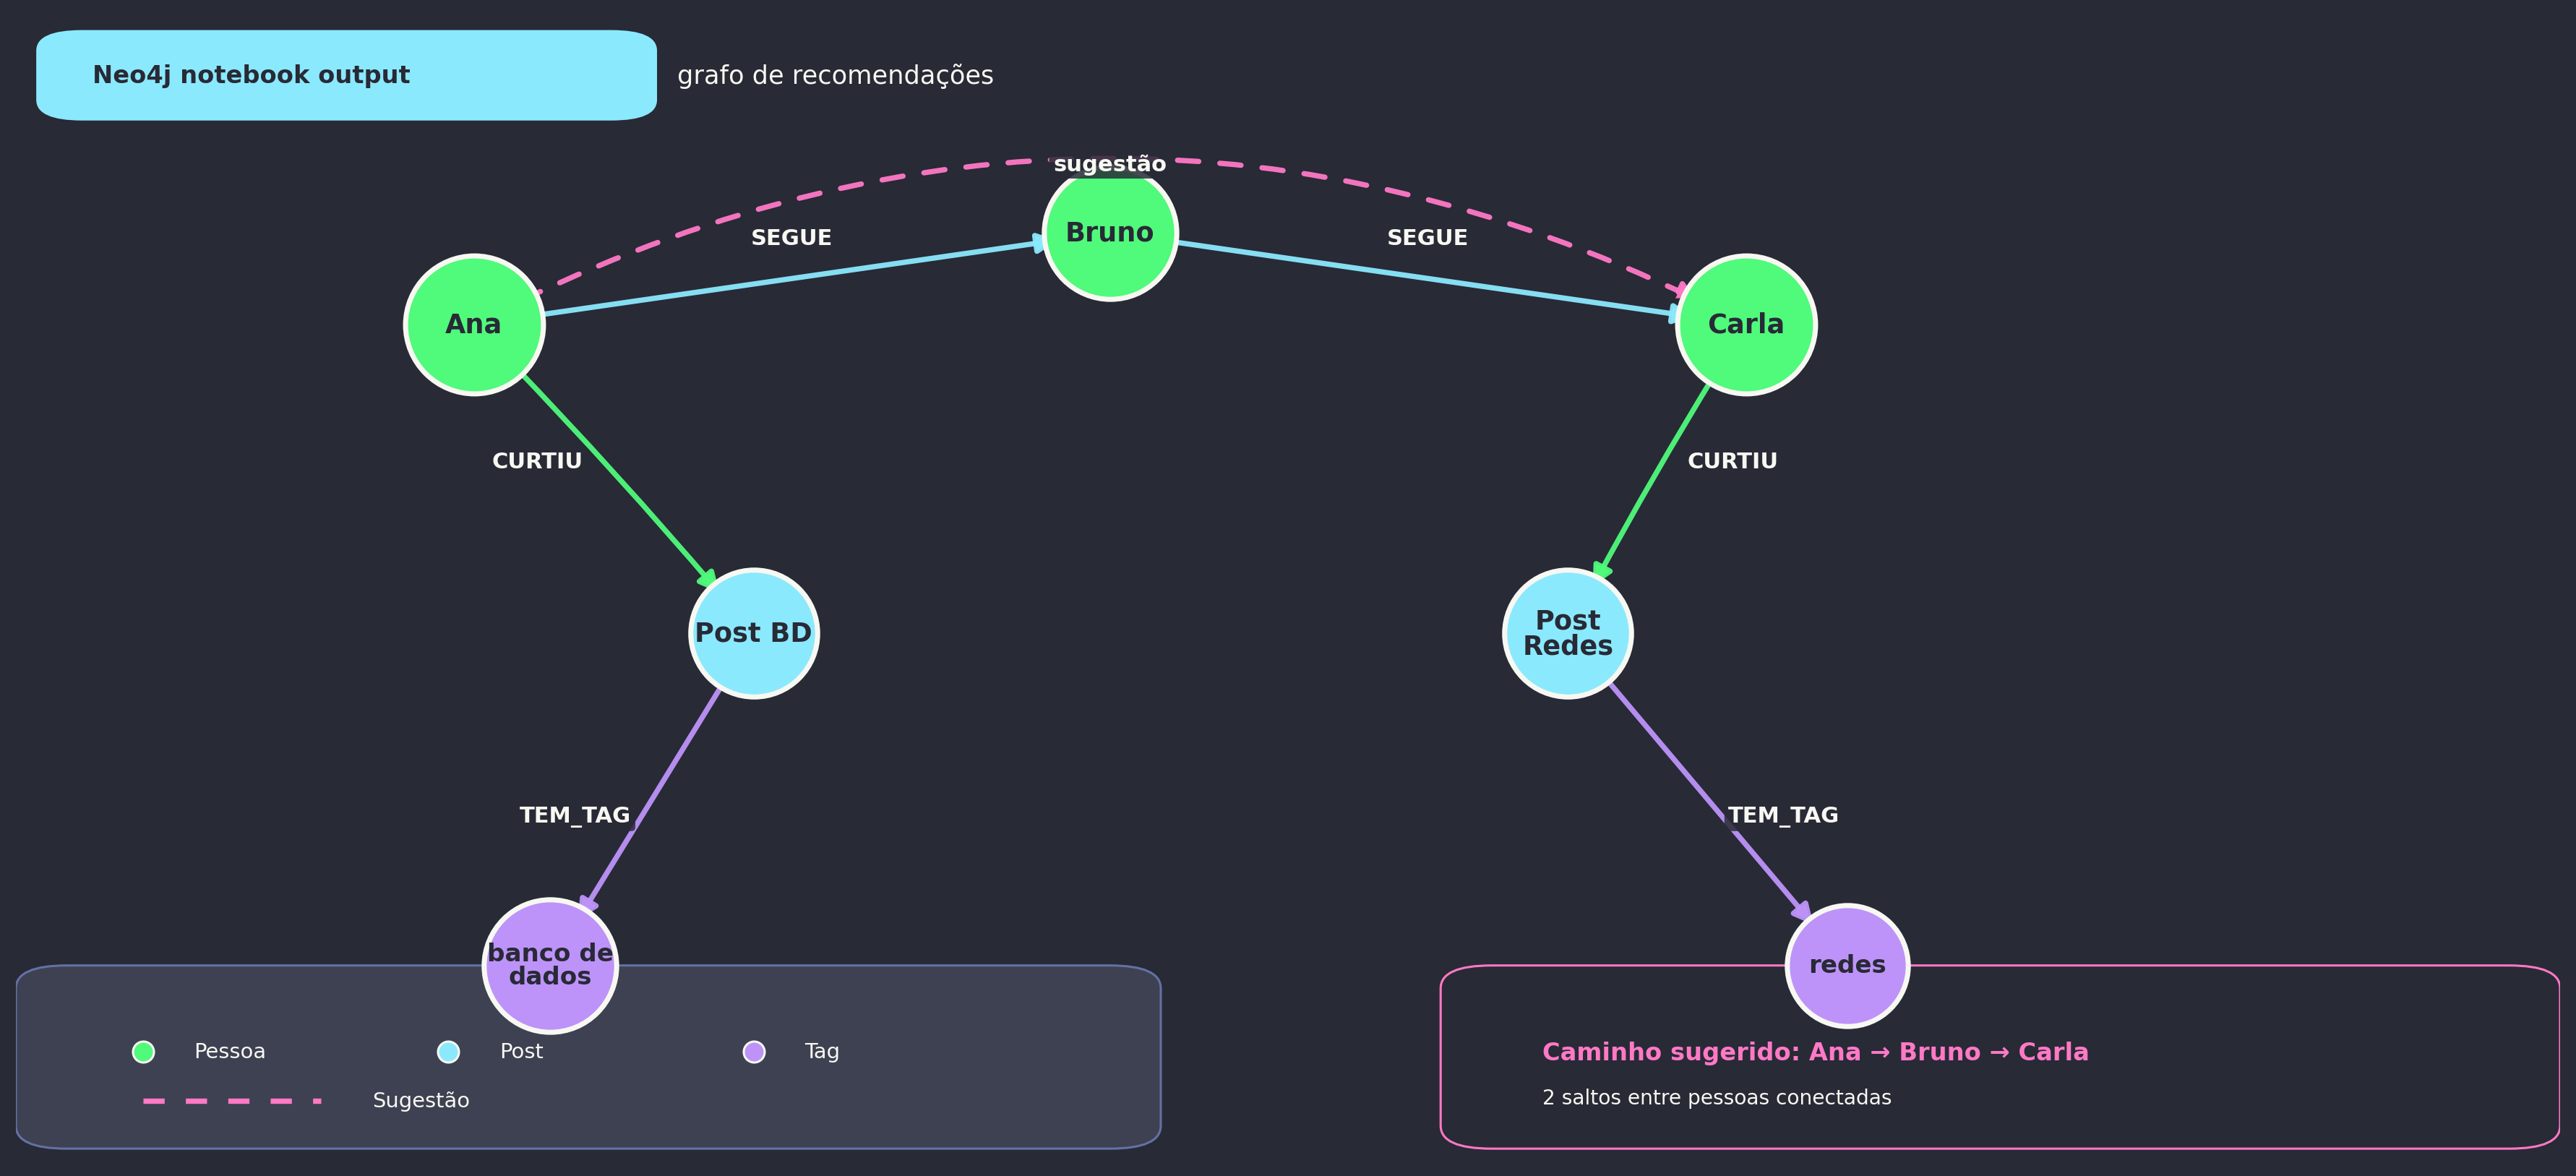

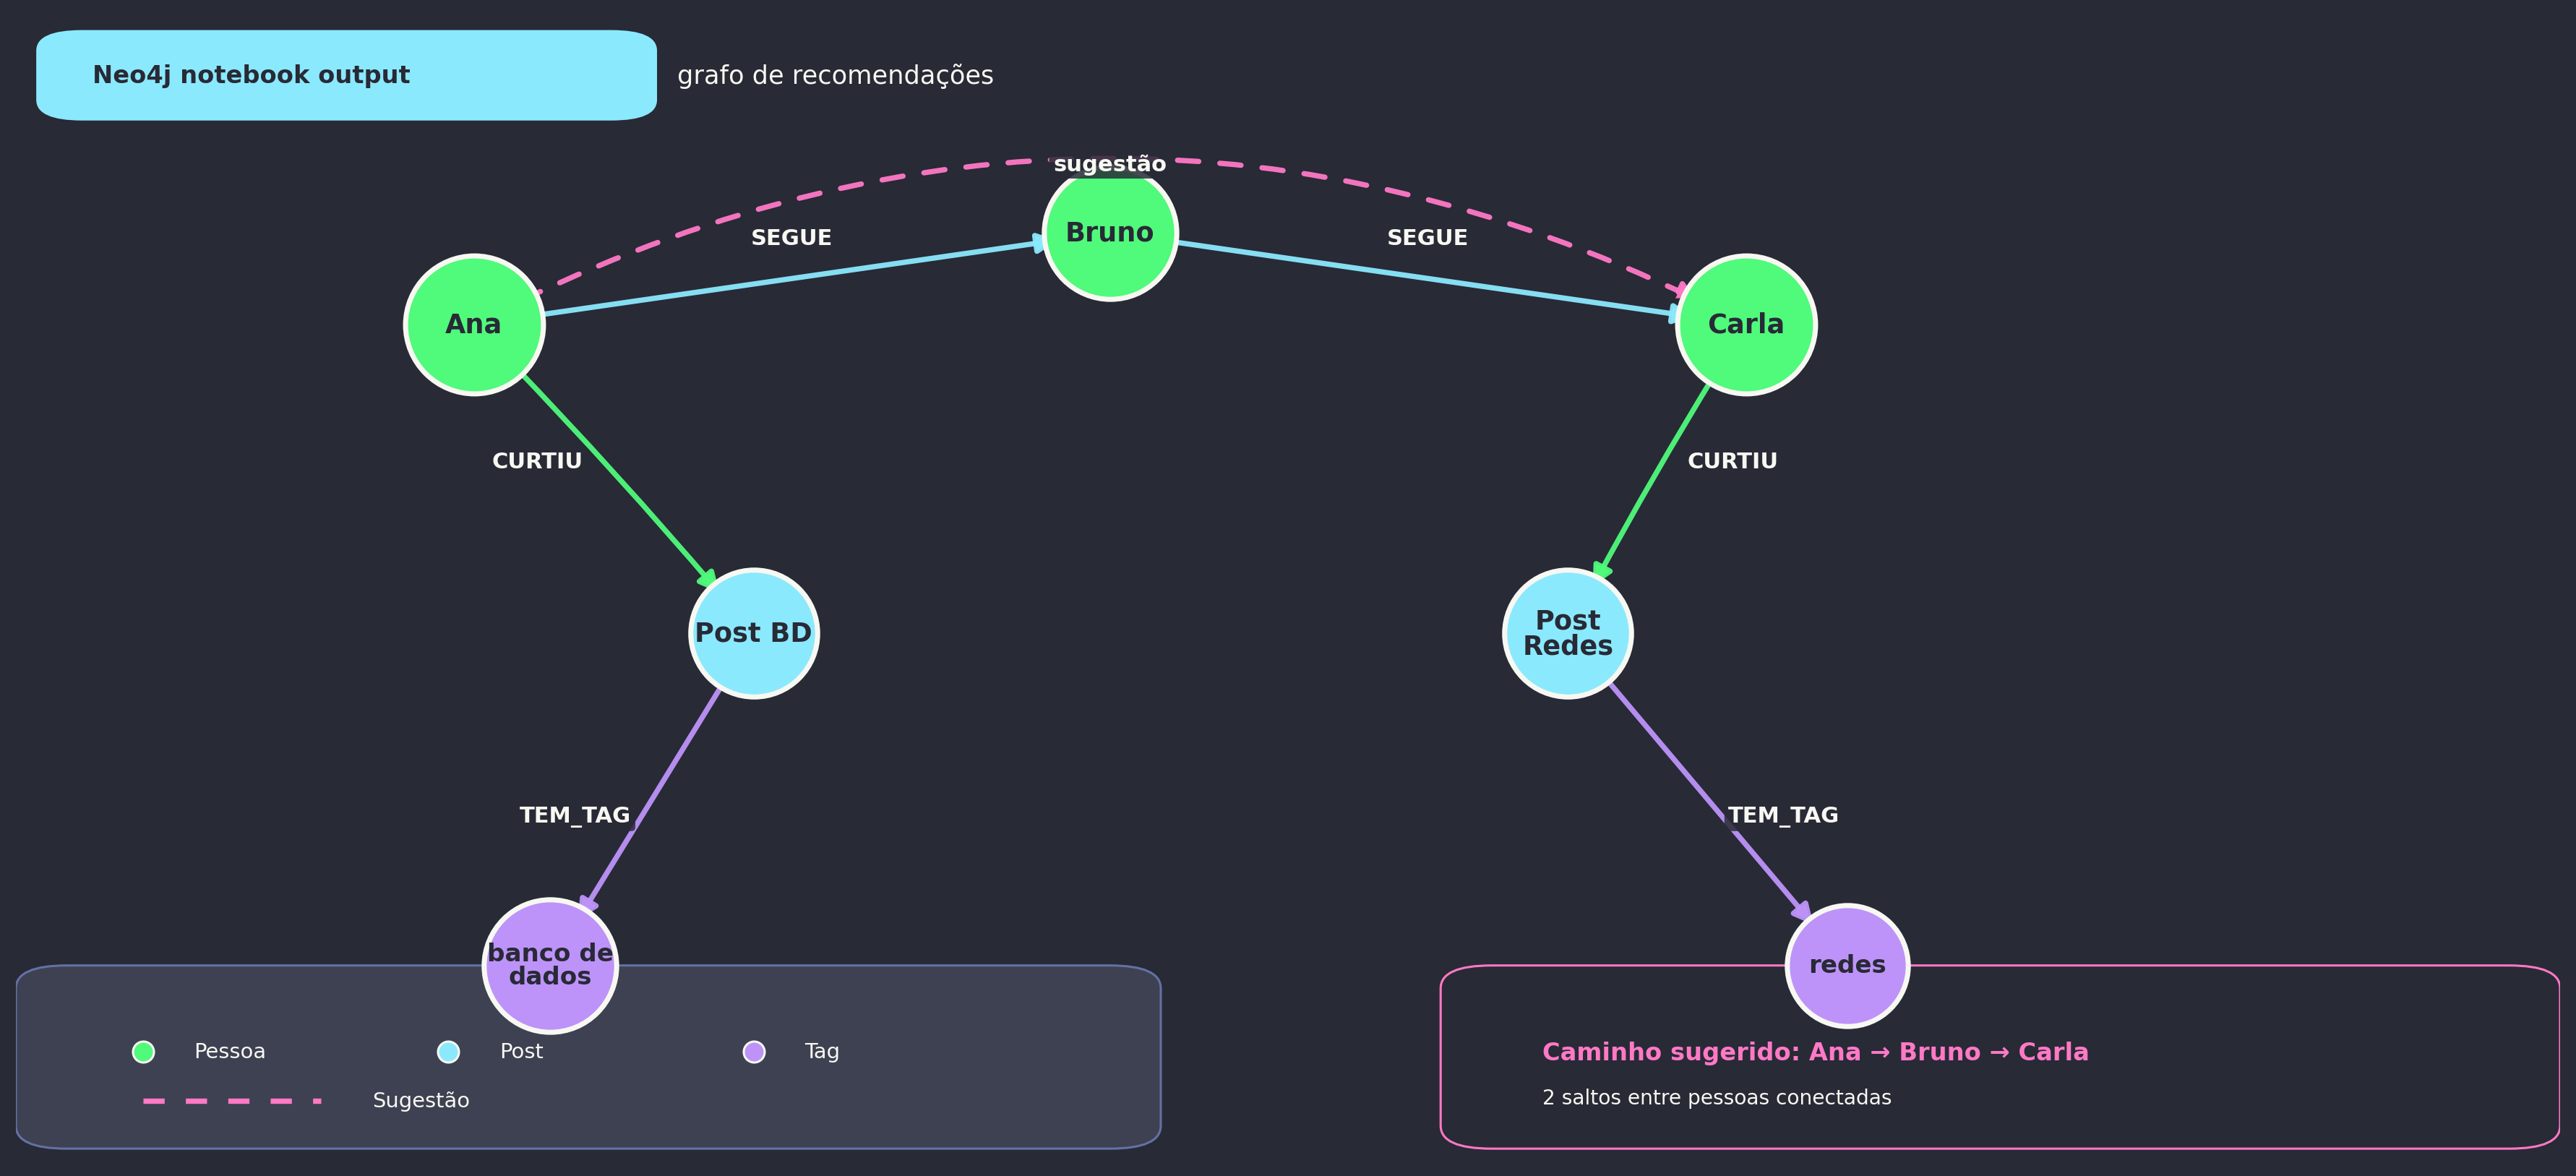

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

out_dir = Path("aula14_neo4j_grafos_assets")
out_dir.mkdir(parents=True, exist_ok=True)
out_file = out_dir / "neo4j-recommendation-graph.png"

bg = "#282a36"
fg = "#f8f8f2"
people = "#50fa7b"
posts = "#8be9fd"
tags = "#bd93f9"
accent = "#ff79c6"

positions = {
    "Ana": (0.18, 0.73),
    "Bruno": (0.43, 0.81),
    "Carla": (0.68, 0.73),
    "Post BD": (0.29, 0.46),
    "Post Redes": (0.61, 0.46),
    "banco de dados": (0.21, 0.17),
    "redes": (0.72, 0.17),
}

node_types = {
    "Ana": "Pessoa",
    "Bruno": "Pessoa",
    "Carla": "Pessoa",
    "Post BD": "Post",
    "Post Redes": "Post",
    "banco de dados": "Tag",
    "redes": "Tag",
}

node_labels = {
    "Ana": "Ana",
    "Bruno": "Bruno",
    "Carla": "Carla",
    "Post BD": "Post BD",
    "Post Redes": "Post\nRedes",
    "banco de dados": "banco de\ndados",
    "redes": "redes",
}

node_sizes = {
    "Ana": 3900,
    "Bruno": 3600,
    "Carla": 3900,
    "Post BD": 3300,
    "Post Redes": 3300,
    "banco de dados": 3600,
    "redes": 3000,
}

node_colors = {
    "Pessoa": people,
    "Post": posts,
    "Tag": tags,
}

fig = plt.figure(figsize=(16, 7.2), facecolor=bg, dpi=220)
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_facecolor(bg)
ax.axis("off")

chip = FancyBboxPatch(
    (0.02, 0.92),
    0.22,
    0.055,
    boxstyle="round,pad=0.012,rounding_size=0.018",
    facecolor=posts,
    edgecolor="none",
    zorder=1,
)
ax.add_patch(chip)
ax.text(
    0.03,
    0.947,
    "Neo4j notebook output",
    transform=ax.transAxes,
    color=bg,
    fontsize=11,
    fontweight="bold",
    va="center",
    zorder=2,
)
ax.text(
    0.26,
    0.947,
    "grafo de recomendações",
    transform=ax.transAxes,
    color=fg,
    fontsize=11.5,
    va="center",
    zorder=2,
)


def draw_node(name):
    x, y = positions[name]
    kind = node_types[name]
    ax.scatter(
        [x],
        [y],
        s=node_sizes[name],
        color=node_colors[kind],
        edgecolors=fg,
        linewidths=2.3,
        zorder=3,
    )
    ax.text(
        x,
        y,
        node_labels[name],
        ha="center",
        va="center",
        color=bg,
        fontsize=12 if kind != "Tag" else 11.2,
        fontweight="bold",
        linespacing=0.95,
        zorder=4,
    )


def draw_edge(src, dst, label, color, rad=0.0, linestyle="solid", label_offset=(0.0, 0.0)):
    x1, y1 = positions[src]
    x2, y2 = positions[dst]
    edge = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>",
        mutation_scale=18,
        lw=2.4,
        color=color,
        alpha=0.95,
        linestyle=linestyle,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=24,
        shrinkB=24,
        zorder=2,
    )
    ax.add_patch(edge)
    mx = (x1 + x2) / 2 + label_offset[0]
    my = (y1 + y2) / 2 + label_offset[1]
    ax.text(
        mx,
        my,
        label,
        ha="center",
        va="center",
        fontsize=10,
        color=fg,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.18", facecolor=bg, edgecolor="none", alpha=0.85),
        zorder=5,
    )


draw_edge("Ana", "Bruno", "SEGUE", posts, rad=0.0, label_offset=(0.0, 0.035))
draw_edge("Bruno", "Carla", "SEGUE", posts, rad=0.0, label_offset=(0.0, 0.035))
draw_edge("Ana", "Post BD", "CURTIU", people, rad=-0.02, label_offset=(-0.03, 0.015))
draw_edge("Carla", "Post Redes", "CURTIU", people, rad=0.02, label_offset=(0.03, 0.015))
draw_edge("Post BD", "banco de dados", "TEM_TAG", tags, rad=0.0, label_offset=(-0.03, -0.015))
draw_edge("Post Redes", "redes", "TEM_TAG", tags, rad=0.0, label_offset=(0.03, -0.015))
draw_edge("Ana", "Carla", "sugestão", accent, rad=-0.26, linestyle=(0, (4, 4)), label_offset=(0.0, 0.14))

for node in positions:
    draw_node(node)

legend = FancyBboxPatch(
    (0.02, 0.03),
    0.41,
    0.12,
    boxstyle="round,pad=0.02,rounding_size=0.02",
    facecolor=(68 / 255, 71 / 255, 90 / 255, 0.8),
    edgecolor="#6272a4",
    linewidth=1.0,
    zorder=0,
)
ax.add_patch(legend)

legend_items = [("Pessoa", people), ("Post", posts), ("Tag", tags)]
for index, (label, color) in enumerate(legend_items):
    x = 0.05 + index * 0.12
    ax.scatter(
        [x],
        [0.095],
        s=90,
        color=color,
        edgecolors=fg,
        linewidths=1.0,
        transform=ax.transAxes,
        zorder=6,
        clip_on=False,
    )
    ax.text(
        x + 0.02,
        0.095,
        label,
        transform=ax.transAxes,
        va="center",
        ha="left",
        fontsize=9.5,
        color=fg,
        zorder=6,
    )

ax.plot(
    [0.05, 0.12],
    [0.052, 0.052],
    transform=ax.transAxes,
    color=accent,
    lw=2.4,
    linestyle=(0, (4, 4)),
    zorder=6,
)
ax.text(
    0.14,
    0.052,
    "Sugestão",
    transform=ax.transAxes,
    va="center",
    ha="left",
    fontsize=9.5,
    color=fg,
    zorder=6,
)

caption = FancyBboxPatch(
    (0.58, 0.03),
    0.40,
    0.12,
    boxstyle="round,pad=0.02,rounding_size=0.02",
    facecolor=(40 / 255, 42 / 255, 54 / 255, 0.85),
    edgecolor=accent,
    linewidth=1.0,
    zorder=0,
)
ax.add_patch(caption)
ax.text(
    0.60,
    0.094,
    "Caminho sugerido: Ana → Bruno → Carla",
    transform=ax.transAxes,
    color=accent,
    fontsize=11,
    fontweight="bold",
    va="center",
    zorder=6,
)
ax.text(
    0.60,
    0.054,
    "2 saltos entre pessoas conectadas",
    transform=ax.transAxes,
    color=fg,
    fontsize=9.2,
    va="center",
    zorder=6,
)

fig.savefig(out_file, facecolor=fig.get_facecolor())

display(
    pd.DataFrame(
        [
            {
                "sugerida": "Carla",
                "caminho": "Ana → Bruno → Carla",
                "distancia": 2,
            }
        ]
    )
)

fig